## Processing of sector-level inversion results

This notebook contains code to scale inverse model estimates of total emissions into sector-level emissions, using information from a bottom-up model.

Data from the bottom-up models has been processed into fluxie format flux netcdfs. The proportion of emissions contribution to total emissions in each lat/lon grid cell is used to scale the inversion's esimate of total emissions in that grid cell, into a sector-level emission estimate.
These results are first plotted (as the plotting function also processes results into the correct format).
Then a table of sector-level results are created.

** Currently, results from each model have to be read and processed  in individually. This may be updated in the future. **

See `PARIS_inversion_results.ipynb` for more information about the functions used here to read in and average inversion output.

In [1]:
%load_ext autoreload
%autoreload 2
import logging
logging.basicConfig(level=logging.WARNING)

from fluxie.config import set_print_settings
from fluxie.io import read_config_files

### Path to results directory
data_dir = '/data/users/intem_ghg/inversion/PARIS_results_sharing'

### Set presentation_mode to True for bigger fonts
presentation_mode = False

###################################

config_data = read_config_files()
annotate_coords = set_print_settings(presentation_mode)

### 1. Read in inversion estimate of total emissions

In [5]:
from fluxie.io import read_model_output, read_flux_total_fgases
from fluxie.operators.select import slice_flux
from fluxie.config import set_model_colors
from fluxie.config import set_model_labels
from fluxie.operators.flux_scale_by_sector_proportions import scale_by_sector_proportions

###################################
### edit variables in this block
species = 'ch4' # ch4 (or n2o eventually)
inv_model = 'InTEM'

if inv_model == 'InTEM':
    if species == 'ch4':
        models = ['InTEM_ERA5_EUROPE_NID2026_G',
                'InTEM_NAME_EUROPE_AR2026']
    elif species == 'n2o':
        models = []
    
    start_date = ['1990-01-01','2012-01-01']    # inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
    end_date = ['2012-01-01','2026-01-01']      # not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
    period = ['yearly','monthly']               #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']

elif inv_model == 'RHIME':
    if species == 'ch4':
        models = []
    elif species == 'n2o':
        models = []
    start_date = '1990-01-01'    # inclusive. Option to set as list of dates, e.g. ['2018-01-01','2019-01-01'] which is required for total fgases if one model is missing obs for a year
    end_date = '2026-01-01'      # not inclusive. Option to set as list of dates, e.g. ['2023-01-01','2022-01-01'] which is required for total fgases if one model is missing obs for a year
    period = ['monthly']               #inversion period, must be a string or a list of the same length as models, e.g. ['monthly','yearly']

regions = ['UK']
country_flux_units_print = 'Tg yr-1'        # units for the plot. Add "CO2-eq" to convert the mass to CO2 equivalent (e.g. "Gg CO2-eq yr-1")
get_labels_from_file = True                 # If False, uses default labels. If True, uses labels in models_info.json.
sector_file = 'EUROPE_EDGAR_v2025_CEH_ch4_monthly'  # if not None, adds sector level results by scaling model totals by the sector proportions in this file. Default file: 'EUROPE_EDGAR', inside the 'sector_flux' directory
create_region_sector_totals = True                  #if True, uses country_fraction variable to sum spatial sector fluxes to region sector fluxes
create_sectors = True
read_standard_run = False
only_overlapping = False                            #if True, only uses time periods where all models have data
sectors = ['agriculture','waste','energy','industry']
###################################

if 'all' in species:
    ds_all_flux_scaled = read_flux_total_fgases(data_dir,species,models,config_data,
                                                     regions,start_date,end_date,
                                                     period=period,only_overlapping=only_overlapping)
else:
    ds_all_flux = read_model_output(data_dir,"flux",species,models,config_data,period=period,read_standard_run=read_standard_run)
    ds_all_flux_scaled = slice_flux(ds_all_flux,config_data,start_date,end_date,species=species,country_flux_units_print=country_flux_units_print)

if sector_file is not None:
    ds_all_flux_scaled = scale_by_sector_proportions(data_dir=data_dir,ds_all=ds_all_flux_scaled,
                                                            species=species,
                                                            country_flux_units_print=country_flux_units_print,
                                                            config_data=config_data,regions=regions,
                                                            sector_file=sector_file,create_sectors=create_sectors,
                                                            create_region_sector_totals=create_region_sector_totals,
                                                            sectors=sectors)   

model_colors = set_model_colors(models)
model_labels = set_model_labels(models,config_data,get_labels_from_file)

Working on agriculture...
Working on waste...
Working on energy...
Working on industry...
Working on agriculture...
Working on waste...
Working on energy...
Working on industry...


#### 2. Process data into one timeseries and create a plot of country fluxes:

Results from mulitple inversions (e.g. InTEM annual results 1990-2012 and InTEM's monthly results 2012-2026) are combined into one timeseries, using a 3-yearly rolling mean and monthly to yearly averaging. Data is processed into a format that can be printed into a table, using the next section. 

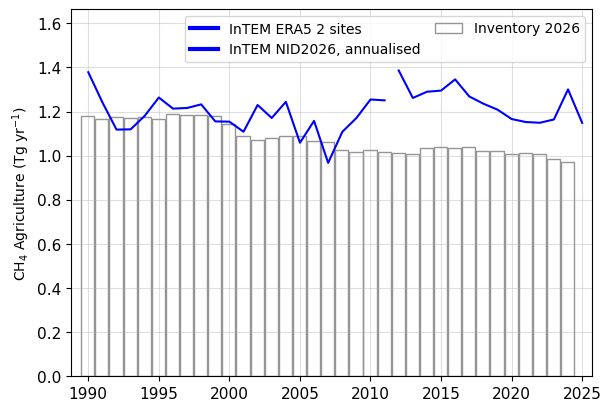

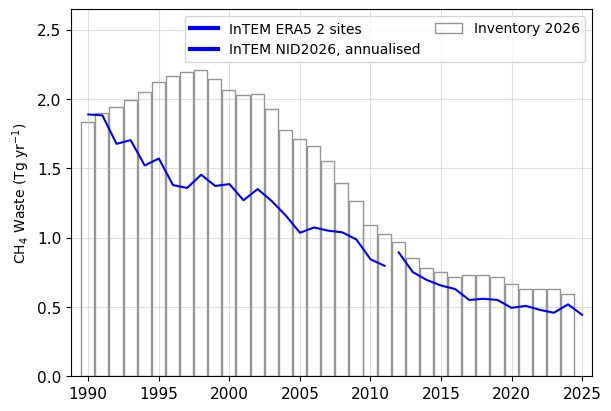

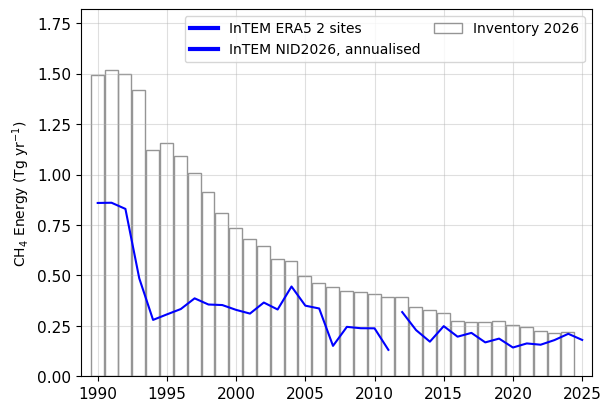

In [20]:
from fluxie.plots.flux_timeseries import plot_country_flux
import pandas as pd
###################################
### edit variables in this block
sectors = ['agriculture','waste','energy']
plot_inventory = True
plot_inventory_uncertainty = [False]    #Either True/False or a list of True/False to match length of inventory_years
inventory_years = ['2026'] #If None, plots most recent. Or can choose list of years: ['2022','2023']
inventory_filename = 'UNFCCC_inventory'   #Full filename = {inventory_filename}_{species}_{inventory_year}
fix_y_axes = False #[0,75] #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior = False #if True: plots prior as dashed lines
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = False #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles. Set to None for no title.
plot_separate = False #If True, includes all model results as separate lines (or insert a list of boolean of the same length as models to specify which models to plot)
plot_separate_unc = False #If True, includes all model uncertainty as shaded areas
plot_combined = False #If True, combined results, averaged from all models (or insert a list of boolean of the same length as models to specify which models to combine)
combined_models_dict = None #To plot multiple combined results, use (e.g.) combined_models_dict = {'NAME Mean': ['InTEM_NAME', 'ELRIS_NAME'], 'FLEXPART Mean': ['InTEM_FLEXPART', 'ELRIS_FLEXPART']} and set plot_combined = True.
plot_combined_unc = False #If True, includes combined uncertainty as shaded area
resample_uncert_correlation = False #If True, uses mean uncertainty during resampling, if False, recalculates uncertainty assuming no correlation.
plot_resample_and_original = False #If True, plots both the resampled and original data
annex_mode = False #If True, replace the labels with more concise versions for NID Annexes.
aggreg_month = False     # if True, plot the fluxes aggregated by month. Only work with monthly data.
xticks_at_centre = True    # if True, moves x ticks to centre of time periods
plot_grid = True    # if True, adds faint grid to the plots

if inv_model == 'InTEM':
    resample = [None,'year'] #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
    rolling_mean = [3,None] # If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
    
elif inv_model == 'RHIME':
    resample = 'year' #If None, no resample is done. Else resample the data to the given period (options 'year' and 'season' for yearly and seasonal averages)
    rolling_mean = None # If True, calculates a rolling mean of the data (insert a list of boolean of the same length as models to specify the models to smooth)
    
###################################

results_all = {}

for s,sector in enumerate(sectors):

    fig,res = plot_country_flux(ds_all_flux_scaled,
                            species,
                            regions,
                            config_data,
                            model_colors,
                            model_labels,
                            start_date,
                            end_date,
                            annex_mode,
                            plot_inventory,
                            plot_inventory_uncertainty,
                            inventory_years,
                            inventory_filename,
                            data_dir,
                            fix_y_axes,
                            add_prior,
                            add_prior_unc,
                            set_global_leg,
                            country_codes_as_titles=country_codes_as_titles,
                            plot_separate=plot_separate,
                            plot_separate_unc=plot_separate_unc,
                            plot_combined=plot_combined,
                            combined_models_dict = combined_models_dict,
                            plot_combined_unc=plot_combined_unc,
                            resample=resample,
                            resample_uncert_correlation=resample_uncert_correlation,
                            plot_resample_and_original=plot_resample_and_original,
                            rolling_mean=rolling_mean,
                            aggreg_month=aggreg_month,
                            return_res=True,sector=sector,
                            xticks_at_centre=xticks_at_centre,
                            plot_grid=plot_grid,
                            only_overlapping=only_overlapping)
    
    results_all[sector] = res.fillna(0)

#### 3. Create a table of sector-level country fluxes

In [ ]:
from fluxie.cli.MO_annual_report import make_AR_table

###################################
### edit variables in this block
output_dir = 'path_to_save_dir'
output_name = 'output_filename'     #full output filepath = output_dir/species_{output_name}_table.txt
n_digits = 2 #number of decimal places includes in the table values
###################################

results_all_table = make_AR_table(df=results_all,output_dir=output_dir,output_name=output_name,
            inventory_years=inventory_years,species=species,
            s_data=config_data["species_info"],regions=regions,start_date=start_date,
            country_flux_units_print=country_flux_units_print,
            include_inventory_uncert=plot_inventory_uncertainty[0],
            include_inventory=plot_inventory,n_digits=2,save_latex=False,
            save_csv=False,sectors=sectors
            )

agriculture
waste
energy
